# Climate Transition Score for S&P 500 companies

## What this notebook is trying to solve

The ETHack sustainability challenge asks us to build a data-driven framework to compare the sustainability of companies in the S&P 500. Instead of building a broad ESG score, this notebook focuses on one question that is especially relevant for a net-zero transition:

> Which companies look best positioned if the world suddenly commits to reducing emissions as fast as possible?

The source data come from the provided Excel workbook, which contains Bloomberg ESG, emissions, SBTi and financial fields. The notebook first inspects the workbook because Bloomberg field availability can vary by company and year. We only use fields that are actually present in the file.

## Basic idea

The score is organized around three questions:

1. **Where is the company today?**  
   We measure the current emissions footprint using FY2024 emissions intensity.

2. **Is the company actually becoming cleaner?**  
   We estimate realized emissions trends over 2020-2024, separately for absolute emissions and revenue-adjusted emissions intensity.

3. **Is the company credibly positioned to keep reducing emissions?**  
   We use SBTi target status and target ambition as a forward-looking signal.

The baseline architecture is:

\[
\text{Climate Transition Score}
= 30\% \times \text{Current Footprint}
+ 50\% \times \text{Realized Decarbonization}
+ 20\% \times \text{Forward Target}
\]

Realized decarbonization receives the largest weight because observed emissions reductions are stronger evidence than stated commitments alone. The weights are judgement-based and are tested later with a simple robustness experiment.

## Core formulas

For each fiscal year, the notebook calculates:

\[
\text{Scope 1+2 emissions} = \text{Scope 1 emissions} + \text{Scope 2 emissions}
\]

\[
\text{Scope 1+2 intensity} =
\frac{\text{Scope 1+2 emissions}}{\text{Revenue}}
\]

\[
\text{Scope 3 intensity} =
\frac{\text{Scope 3 emissions}}{\text{Revenue}}
\]

Emission trends are estimated with a simple log-linear model:

\[
\log(\text{emissions}_t) = \alpha + \beta \times \text{year}
\]

and converted into an approximate annual percentage change:

\[
\text{annual change} = e^\beta - 1
\]

Negative annual changes are better because they indicate falling emissions. For ranking, the notebook transforms raw variables into 0-100 scores where **100 is best** and **0 is worst**.

## Why the notebook is structured this way

The notebook follows the same order a judge would need to evaluate the score:

1. Inspect the data before making assumptions.
2. Check data quality and reporting coverage.
3. Build emissions and revenue-adjusted intensity variables.
4. Estimate realized decarbonization trends.
5. Normalize companies globally and against peers.
6. Add SBTi target information.
7. Combine components with transparent weights.
8. Adjust for missing data and test robustness.
9. Export a portfolio-ready dataset.

This structure is meant to make the score explainable. A company should not rank highly just because it is in a low-emissions sector, has made a public target, or has missing disclosure. The score therefore combines current footprint, actual historical progress, target credibility, peer comparisons, global comparisons and data-coverage adjustments.


## 1. Load libraries and define file paths

The source files were moved into the project `data` folder so the notebook can be run from the repository. The main source is the provided Bloomberg-derived ESG workbook. The PDF data dictionary is included as a reference document, but the code relies on direct workbook inspection rather than assuming that every documented field is present.

In [5]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Theil-Sen is optional. The core score still works if scipy is unavailable,
# but the robust-slope diagnostic becomes missing rather than blocking the notebook.
try:
    from scipy.stats import theilslopes
except Exception:
    theilslopes = None

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

excel_path = DATA_DIR / "ESGData.xlsx"
dictionary_path = DATA_DIR / "ESGData_Practical_Data_Dictionary.pdf"

print(f"Excel file exists: {excel_path.exists()} -> {excel_path}")
print(f"Data dictionary exists: {dictionary_path.exists()} -> {dictionary_path}")


Excel file exists: True -> c:\Users\axeli\Desktop\Coding\GitHub\Competitions\ETHack2026\data\ESGData.xlsx
Data dictionary exists: True -> c:\Users\axeli\Desktop\Coding\GitHub\Competitions\ETHack2026\data\ESGData_Practical_Data_Dictionary.pdf


## 2. Load and inspect the data

This section identifies the actual sheets, dimensions, identifiers, sector fields, emissions variables, financial variables and SBTi fields in the workbook.


In [6]:
xls = pd.ExcelFile(excel_path)
sheet_names = xls.sheet_names
print("Sheets in workbook:")
for sheet in sheet_names:
    print(f"- {sheet}")

# Load all sheets once so the rest of the notebook can inspect structure and coverage
# before choosing columns for the scoring methodology.
raw_sheets = {sheet: pd.read_excel(excel_path, sheet_name=sheet) for sheet in sheet_names}

sheet_summary = []
for sheet, df in raw_sheets.items():
    sheet_summary.append({
        "sheet": sheet,
        "rows": len(df),
        "columns": df.shape[1],
        "first_columns": ", ".join(df.columns[:8]),
    })
pd.DataFrame(sheet_summary)


Sheets in workbook:
- General_Features
- Scope_Time_Series
- Financial_Time_Series


,sheet,rows,columns,first_columns
0,General_Features,503,57,"ID, name(), id_isin(), gics_sector_name(), GIC..."
1,Scope_Time_Series,503,25,"ID, name(), id_isin(), gics_sector_name(), GHG..."
2,Financial_Time_Series,503,39,"ID, name(), id_isin(), gics_sector_name(), SAL..."


In [7]:
general = raw_sheets.get("General_Features").copy()
scope_ts = raw_sheets.get("Scope_Time_Series").copy()
financial_ts = raw_sheets.get("Financial_Time_Series").copy()

# These groups are a compact audit trail: they show which Bloomberg-style fields
# are actually available before we calculate any score components.
important_column_groups = {
    "Identifier columns": [c for c in general.columns if c in ["ID", "name()", "id_isin()"]],
    "Sector / peer columns": [c for c in general.columns if "gics" in c.lower() or "industry" in c.lower()],
    "General emissions columns": [c for c in general.columns if "GHG" in c or "EMISSIONS" in c],
    "SBTi columns": [c for c in general.columns if "SBTI" in c],
    "Scope time-series columns": [c for c in scope_ts.columns if "GHG_SCOPE" in c],
    "Financial time-series columns": [c for c in financial_ts.columns if any(x in c for x in ["SALES_REV", "EBITDA", "CAP", "ASSET", "EMPLOYEE"])],
}

for label, columns in important_column_groups.items():
    print(f"\n{label} ({len(columns)}):")
    print(columns)



Identifier columns (3):
['ID', 'name()', 'id_isin()']

Sector / peer columns (2):
['gics_sector_name()', 'GICS_INDUSTRY_GROUP_NAME']

General emissions columns (4):
['GHG_SCOPE_1', 'GHG_SCOPE_2', 'GHG_SCOPE_3', 'TOTAL_GHG_EMISSIONS']

SBTi columns (2):
['SBTI_NEAR_TERM_TARGET_STATUS', 'SBTI_NEAR_TERM_TARGET_CLASS']

Scope time-series columns (21):
['GHG_SCOPE_1_2019', 'GHG_SCOPE_1_2020', 'GHG_SCOPE_1_2021', 'GHG_SCOPE_1_2022', 'GHG_SCOPE_1_2023', 'GHG_SCOPE_1_2024', 'GHG_SCOPE_1_2025', 'GHG_SCOPE_2_2019', 'GHG_SCOPE_2_2020', 'GHG_SCOPE_2_2021', 'GHG_SCOPE_2_2022', 'GHG_SCOPE_2_2023', 'GHG_SCOPE_2_2024', 'GHG_SCOPE_2_2025', 'GHG_SCOPE_3_2019', 'GHG_SCOPE_3_2020', 'GHG_SCOPE_3_2021', 'GHG_SCOPE_3_2022', 'GHG_SCOPE_3_2023', 'GHG_SCOPE_3_2024', 'GHG_SCOPE_3_2025']

Financial time-series columns (35):
['SALES_REV_TURN_2019', 'SALES_REV_TURN_2020', 'SALES_REV_TURN_2021', 'SALES_REV_TURN_2022', 'SALES_REV_TURN_2023', 'SALES_REV_TURN_2024', 'SALES_REV_TURN_2025', 'BS_TOT_ASSET_2019', 'BS_TOT_

In [8]:
id_summary = pd.DataFrame({
    "sheet": ["General_Features", "Scope_Time_Series", "Financial_Time_Series"],
    "security_rows": [len(general), len(scope_ts), len(financial_ts)],
    "unique_ID": [general["ID"].nunique(), scope_ts["ID"].nunique(), financial_ts["ID"].nunique()],
    "unique_company_names": [general["name()"].nunique(), scope_ts["name()"].nunique(), financial_ts["name()"].nunique()],
    "duplicated_company_rows": [general["name()"].duplicated().sum(), scope_ts["name()"].duplicated().sum(), financial_ts["name()"].duplicated().sum()],
})
id_summary


,sheet,security_rows,unique_ID,unique_company_names,duplicated_company_rows
0,General_Features,503,503,500,3
1,Scope_Time_Series,503,503,500,3
2,Financial_Time_Series,503,503,500,3


In [9]:
duplicate_issuers = (
    general.groupby("name()", dropna=False)
    .agg(security_count=("ID", "nunique"), ids=("ID", lambda x: ", ".join(x.dropna().astype(str).head(5))))
    .query("security_count > 1")
    .sort_values("security_count", ascending=False)
)

print(f"Companies with more than one security row: {len(duplicate_issuers)}")
duplicate_issuers.head(10)


Companies with more than one security row: 3


,security_count,ids
name(),,
Alphabet Inc,2,"GOOG UW Equity, GOOGL UW Equity"
Fox Corp,2,"FOX UW Equity, FOXA UW Equity"
News Corp,2,"NWS UW Equity, NWSA UW Equity"


## 3. Data quality checks

The score does not replace missing Bloomberg observations with zero. Observed zero and missing values are kept separate.

FY2024 is used as the common current year. FY2025 is treated as optional/latest information because coverage is visibly incomplete in many financial and emissions datasets.


In [10]:
def safe_numeric(series):
    '''Convert a pandas Series to numeric while preserving missing values.'''
    return pd.to_numeric(series, errors="coerce")


# Missingness is part of the sustainability signal because non-disclosure should
# lower confidence, but it should not be treated as zero emissions.
def compact_missing_summary(df, columns):
    '''Return a compact missing-value summary for selected columns.'''
    rows = []
    for col in columns:
        if col in df.columns:
            rows.append({
                "column": col,
                "missing": int(df[col].isna().sum()),
                "missing_pct": df[col].isna().mean(),
                "non_missing": int(df[col].notna().sum()),
                "zeros": int((safe_numeric(df[col]) == 0).sum()) if pd.api.types.is_numeric_dtype(safe_numeric(df[col])) else np.nan,
            })
    return pd.DataFrame(rows).sort_values("missing_pct", ascending=False)


scope_columns = [c for c in scope_ts.columns if c.startswith("GHG_SCOPE")]
revenue_columns = [c for c in financial_ts.columns if c.startswith("SALES_REV_TURN")]
sbt_columns = [c for c in general.columns if c.startswith("SBTI")]

print("Emissions coverage:")
display(compact_missing_summary(scope_ts, scope_columns))

print("Revenue coverage:")
display(compact_missing_summary(financial_ts, revenue_columns))

print("SBTi coverage:")
display(compact_missing_summary(general, sbt_columns))


Emissions coverage:


,column,missing,missing_pct,non_missing,zeros
20,GHG_SCOPE_3_2025,214,0.425447,289,0
13,GHG_SCOPE_2_2025,182,0.361829,321,0
6,GHG_SCOPE_1_2025,165,0.328032,338,0
14,GHG_SCOPE_3_2019,156,0.310139,347,1
15,GHG_SCOPE_3_2020,134,0.266402,369,0
7,GHG_SCOPE_2_2019,121,0.240557,382,1
16,GHG_SCOPE_3_2021,106,0.210736,397,2
0,GHG_SCOPE_1_2019,100,0.198807,403,2
17,GHG_SCOPE_3_2022,92,0.182903,411,0
19,GHG_SCOPE_3_2024,80,0.159046,423,1


Revenue coverage:


,column,missing,missing_pct,non_missing,zeros
0,SALES_REV_TURN_2019,10,0.019881,493,0
1,SALES_REV_TURN_2020,8,0.015905,495,0
2,SALES_REV_TURN_2021,4,0.007952,499,0
3,SALES_REV_TURN_2022,3,0.005964,500,0
4,SALES_REV_TURN_2023,2,0.003976,501,0
5,SALES_REV_TURN_2024,1,0.001988,502,0
6,SALES_REV_TURN_2025,0,0.000000,503,0


SBTi coverage:


,column,missing,missing_pct,non_missing,zeros
1,SBTI_NEAR_TERM_TARGET_CLASS,38,0.075547,465,0
0,SBTI_NEAR_TERM_TARGET_STATUS,0,0.000000,503,0


In [11]:
duplicate_columns = {}
for sheet_name, df in raw_sheets.items():
    duplicate_columns[sheet_name] = df.columns[df.columns.duplicated()].tolist()

duplicate_columns


{'General_Features': [], 'Scope_Time_Series': [], 'Financial_Time_Series': []}

In [12]:
def find_identical_columns(df, candidate_columns):
    '''Find pairs of columns with identical values, treating missing values consistently.'''
    identical_pairs = []
    for i, left in enumerate(candidate_columns):
        for right in candidate_columns[i + 1:]:
            left_values = df[left]
            right_values = df[right]
            if left_values.equals(right_values):
                identical_pairs.append((left, right))
    return identical_pairs


# The data dictionary warned about a possible Scope 2 2019 issue. We verify the
# actual workbook instead of assuming that the documented issue is still present.
scope_2019_cols = [c for c in scope_ts.columns if c.endswith("_2019")]
scope_2019_identical_pairs = find_identical_columns(scope_ts, scope_2019_cols)

scope2_2019_check = pd.DataFrame({
    "check": [
        "GHG_SCOPE_2_2019 column present",
        "GHG_SCOPE_1_2019 equals GHG_SCOPE_2_2019 exactly",
        "Non-missing GHG_SCOPE_2_2019 observations",
    ],
    "result": [
        "GHG_SCOPE_2_2019" in scope_ts.columns,
        scope_ts["GHG_SCOPE_1_2019"].equals(scope_ts["GHG_SCOPE_2_2019"]) if {"GHG_SCOPE_1_2019", "GHG_SCOPE_2_2019"}.issubset(scope_ts.columns) else np.nan,
        int(scope_ts["GHG_SCOPE_2_2019"].notna().sum()) if "GHG_SCOPE_2_2019" in scope_ts.columns else 0,
    ],
})

print("Identical 2019 scope-column pairs:")
print(scope_2019_identical_pairs)
scope2_2019_check


Identical 2019 scope-column pairs:
[]


,check,result
0,GHG_SCOPE_2_2019 column present,True
1,GHG_SCOPE_1_2019 equals GHG_SCOPE_2_2019 exactly,False
2,Non-missing GHG_SCOPE_2_2019 observations,382


In [13]:
quality_rows = []
for col in scope_columns:
    values = safe_numeric(scope_ts[col])
    quality_rows.append({
        "column": col,
        "negative_values": int((values < 0).sum()),
        "zero_values": int((values == 0).sum()),
        "p99": values.quantile(0.99),
        "max": values.max(),
    })

for col in revenue_columns:
    values = safe_numeric(financial_ts[col])
    quality_rows.append({
        "column": col,
        "negative_values": int((values < 0).sum()),
        "zero_values": int((values == 0).sum()),
        "p99": values.quantile(0.99),
        "max": values.max(),
    })

pd.DataFrame(quality_rows)


,column,negative_values,zero_values,p99,max
0,GHG_SCOPE_1_2019,0,2,64740.774766,1.055230e+05
1,GHG_SCOPE_1_2020,0,2,53644.989453,9.700000e+04
2,GHG_SCOPE_1_2021,0,4,56515.905000,9.874960e+04
3,GHG_SCOPE_1_2022,0,2,51843.200000,9.700000e+04
4,GHG_SCOPE_1_2023,0,1,46378.216016,9.300000e+04
5,GHG_SCOPE_1_2024,0,1,48973.208516,9.200000e+04
6,GHG_SCOPE_1_2025,0,0,54410.922422,9.260250e+04
7,GHG_SCOPE_2_2019,0,1,9171.000000,2.080600e+04
8,GHG_SCOPE_2_2020,0,1,7802.000000,1.981800e+04
9,GHG_SCOPE_2_2021,0,5,6953.000000,2.141300e+04


## 4. Build annual emissions variables

For each year from 2020 to 2024:

\[
\text{Scope 1+2} = \text{Scope 1} + \text{Scope 2}
\]

\[
\text{Emission intensity} = \frac{\text{emissions}}{\text{revenue}}
\]

Scope 1+2 and Scope 3 are kept separate because Scope 3 reporting boundaries differ substantially across firms. `TOTAL_GHG_EMISSIONS` is not added to Scope 1+2 because it may duplicate information already contained in the scope fields.


In [14]:
YEARS = list(range(2020, 2025))
CURRENT_YEAR = 2024

id_columns = ["ID", "name()", "id_isin()", "gics_sector_name()"]
if "GICS_INDUSTRY_GROUP_NAME" in general.columns:
    id_columns.append("GICS_INDUSTRY_GROUP_NAME")

company_base = general[id_columns + sbt_columns].copy()
company_base = company_base.rename(columns={
    "name()": "Company",
    "id_isin()": "ISIN",
    "gics_sector_name()": "GICS Sector",
    "GICS_INDUSTRY_GROUP_NAME": "GICS Industry Group",
})

emissions_wide = scope_ts[["ID"]].copy()
financial_wide = financial_ts[["ID"]].copy()

# Build Scope 1+2 and intensity variables year by year so missing years remain
# visible and FY2025 does not quietly enter the baseline trend window.
for year in YEARS:
    scope1_col = f"GHG_SCOPE_1_{year}"
    scope2_col = f"GHG_SCOPE_2_{year}"
    scope3_col = f"GHG_SCOPE_3_{year}"
    revenue_col = f"SALES_REV_TURN_{year}"

    emissions_wide[f"Scope1_{year}"] = safe_numeric(scope_ts[scope1_col]) if scope1_col in scope_ts.columns else np.nan
    emissions_wide[f"Scope2_{year}"] = safe_numeric(scope_ts[scope2_col]) if scope2_col in scope_ts.columns else np.nan
    emissions_wide[f"Scope3_{year}"] = safe_numeric(scope_ts[scope3_col]) if scope3_col in scope_ts.columns else np.nan
    emissions_wide[f"Scope12_{year}"] = emissions_wide[f"Scope1_{year}"] + emissions_wide[f"Scope2_{year}"]

    financial_wide[f"Revenue_{year}"] = safe_numeric(financial_ts[revenue_col]) if revenue_col in financial_ts.columns else np.nan

analysis = company_base.merge(emissions_wide, on="ID", how="left").merge(financial_wide, on="ID", how="left")

for year in YEARS:
    revenue = analysis[f"Revenue_{year}"]
    # Revenue is used only as a denominator. Zero or negative revenue would make the
# intensity ratio economically meaningless, so those denominators are set missing.
    valid_revenue = revenue.where(revenue > 0)
    analysis[f"Scope12_Intensity_{year}"] = analysis[f"Scope12_{year}"] / valid_revenue
    analysis[f"Scope3_Intensity_{year}"] = analysis[f"Scope3_{year}"] / valid_revenue

scale_check_columns = [
    "Company", "ID", "Scope12_2024", "Scope3_2024", "Revenue_2024",
    "Scope12_Intensity_2024", "Scope3_Intensity_2024"
]
analysis[scale_check_columns].sort_values("Scope12_2024", ascending=False).head(10)


,Company,ID,Scope12_2024,Scope3_2024,Revenue_2024,Scope12_Intensity_2024,Scope3_Intensity_2024
496,ExxonMobil Holdings Corp,XOM UN Equity,100000.000000,730000.000000,339247.000,0.294770,2.151824
474,Vistra Corp,VST UN Equity,86409.159561,20725.800781,17224.000,5.016788,1.203309
146,Duke Energy Corp,DUK UN Equity,80010.000000,27607.699219,30357.000,2.635636,0.909434
409,Southern Co/The,SO UN Equity,79518.164551,34242.898438,26724.000,2.975534,1.281354
124,Chevron Corp,CVX UN Equity,55000.000000,616000.000000,193414.000,0.284364,3.184878
13,American Electric Power Co Inc,AEP UW Equity,47998.130737,36440.000000,19721.300,2.433822,1.847748
327,NextEra Energy Inc,NEE UN Equity,43434.458338,65.222504,24753.000,1.754715,0.002635
168,Entergy Corp,ETR UN Equity,43184.849219,27342.199219,11879.653,3.635194,2.301599
311,Marathon Petroleum Corp,MPC UN Equity,40900.000000,405000.000000,138864.000,0.294533,2.916523
453,United Airlines Holdings Inc,UAL UW Equity,38680.207993,20814.400391,57063.000,0.677851,0.364762


The emissions and revenue variables are used in their reported workbook units. A constant scaling factor does not affect percentile rankings, but the unit consistency matters for interpretation. The table above helps check the order of magnitude before ratios are used.


In [15]:
useful_data_cols = (
    [f"Scope12_{year}" for year in YEARS] +
    [f"Scope3_{year}" for year in YEARS] +
    [f"Revenue_{year}" for year in YEARS] +
    [f"Scope12_Intensity_{year}" for year in YEARS] +
    [f"Scope3_Intensity_{year}" for year in YEARS] +
    sbt_columns
)

# Some issuers have multiple security rows. Keep the row with the most usable
# sustainability information, then preserve all security IDs for later mapping.
analysis["row_data_points"] = analysis[useful_data_cols].notna().sum(axis=1)

company_level = (
    analysis.sort_values(["Company", "row_data_points"], ascending=[True, False])
    .drop_duplicates("Company", keep="first")
    .copy()
)

security_map = (
    analysis.groupby("Company", dropna=False)
    .agg(
        Security_IDs=("ID", lambda x: ", ".join(x.dropna().astype(str).unique())),
        Security_Count=("ID", "nunique"),
    )
    .reset_index()
)
company_level = company_level.merge(security_map, on="Company", how="left")

print(f"Security rows before collapsing share classes: {len(analysis)}")
print(f"Company rows after collapsing duplicate company names: {len(company_level)}")
company_level[["Company", "ID", "Security_Count", "Security_IDs"]].query("Security_Count > 1").head(10)


Security rows before collapsing share classes: 503
Company rows after collapsing duplicate company names: 500


,Company,ID,Security_Count,Security_IDs
22,Alphabet Inc,GOOG UW Equity,2,"GOOG UW Equity, GOOGL UW Equity"
202,Fox Corp,FOX UW Equity,2,"FOX UW Equity, FOXA UW Equity"
333,News Corp,NWS UW Equity,2,"NWS UW Equity, NWSA UW Equity"


## 5. Current Footprint component

The current footprint uses FY2024:

1. Scope 1+2 emissions intensity.
2. Scope 3 emissions intensity.

Lower intensity is better. Intensities are transformed with `log1p` and winsorized at the 1st and 99th percentiles before ranking, because emissions intensity is highly skewed.


In [16]:
def winsorize_series(series, lower=0.01, upper=0.99):
    '''Clip a numeric Series at chosen quantiles.'''
    values = safe_numeric(series)
    lower_q = values.quantile(lower)
    upper_q = values.quantile(upper)
    return values.clip(lower_q, upper_q)


# Intensities are heavily skewed. log1p reduces scale dominance, while winsorizing
# prevents a few extreme observations from driving percentile ranks.
for col in ["Scope12_Intensity_2024", "Scope3_Intensity_2024"]:
    transformed_col = f"log_{col}"
    winsor_col = f"winsor_{transformed_col}"
    company_level[transformed_col] = np.log1p(company_level[col])
    company_level[winsor_col] = winsorize_series(company_level[transformed_col])

footprint_distribution = company_level[[
    "Scope12_Intensity_2024", "Scope3_Intensity_2024",
    "log_Scope12_Intensity_2024", "log_Scope3_Intensity_2024",
    "winsor_log_Scope12_Intensity_2024", "winsor_log_Scope3_Intensity_2024",
]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

footprint_distribution


,count,mean,std,min,1%,5%,50%,95%,99%,max
Scope12_Intensity_2024,453.0,0.195652,0.592728,0.000103,0.000251,0.000759,0.017900,1.014615,3.129543,5.016788
Scope3_Intensity_2024,420.0,1.598052,7.775294,0.000000,0.000331,0.002442,0.178005,5.351410,27.606264,130.412113
log_Scope12_Intensity_2024,453.0,0.121151,0.284260,0.000103,0.000251,0.000759,0.017741,0.700417,1.417414,1.794554
log_Scope3_Intensity_2024,420.0,0.441710,0.685360,0.000000,0.000331,0.002439,0.163823,1.848677,3.352878,4.878338
winsor_log_Scope12_Intensity_2024,453.0,0.119057,0.273439,0.000251,0.000262,0.000759,0.017741,0.700417,1.398042,1.417414
winsor_log_Scope3_Intensity_2024,420.0,0.435641,0.653615,0.000331,0.000333,0.002439,0.163823,1.848677,3.337552,3.352878


## 6. Realized Decarbonization component

For each company, a simple log-linear trend is fitted over 2020-2024:

\[
\log(\text{emissions}_t) = \alpha + \beta \times \text{year}
\]

The slope is converted into an approximate annual percentage change:

\[
\text{annual change} = \exp(\beta) - 1
\]

A value of `-0.08` means emissions decreased by roughly 8% per year. At least three valid positive yearly observations are required.


In [17]:
def estimate_log_trend(row, value_columns, years):
    '''Estimate OLS and Theil-Sen log trends for one company row.'''
    values = safe_numeric(row[value_columns])
    x_values = np.array(years, dtype=float)
    y_values = values.to_numpy(dtype=float)

    # Log trends require positive observations. Requiring at least three valid years
# avoids estimating a transition path from one or two noisy disclosures.
    valid = np.isfinite(y_values) & (y_values > 0)
    if valid.sum() < 3:
        return pd.Series({
            "annual_change": np.nan,
            "ols_beta": np.nan,
            "theil_sen_annual_change": np.nan,
            "valid_years": int(valid.sum()),
        })

    x_valid = x_values[valid]
    log_y_valid = np.log(y_values[valid])

    # A straight-line slope in log emissions is easy to interpret as an approximate
# annual percentage change after applying exp(beta) - 1.
    ols_beta, ols_alpha = np.polyfit(x_valid, log_y_valid, 1)
    annual_change = np.exp(ols_beta) - 1

    if theilslopes is not None and valid.sum() >= 3:
        theil_beta = theilslopes(log_y_valid, x_valid).slope
        theil_annual_change = np.exp(theil_beta) - 1
    else:
        theil_annual_change = np.nan

    return pd.Series({
        "annual_change": annual_change,
        "ols_beta": ols_beta,
        "theil_sen_annual_change": theil_annual_change,
        "valid_years": int(valid.sum()),
    })


trend_specs = {
    "Scope12_Absolute": [f"Scope12_{year}" for year in YEARS],
    "Scope12_Intensity": [f"Scope12_Intensity_{year}" for year in YEARS],
    "Scope3_Absolute": [f"Scope3_{year}" for year in YEARS],
    "Scope3_Intensity": [f"Scope3_Intensity_{year}" for year in YEARS],
}

for label, columns in trend_specs.items():
    trend_result = company_level.apply(lambda row: estimate_log_trend(row, columns, YEARS), axis=1)
    company_level[f"{label}_Trend"] = trend_result["annual_change"]
    company_level[f"{label}_OLS_Beta"] = trend_result["ols_beta"]
    company_level[f"{label}_TheilSen_Trend"] = trend_result["theil_sen_annual_change"]
    company_level[f"{label}_Valid_Years"] = trend_result["valid_years"]

trend_columns = [
    "Company",
    "Scope12_Absolute_Trend", "Scope12_Intensity_Trend",
    "Scope3_Absolute_Trend", "Scope3_Intensity_Trend",
]
company_level[trend_columns].describe(percentiles=[0.05, 0.5, 0.95]).T


,count,mean,std,min,5%,50%,95%,max
Scope12_Absolute_Trend,451.0,0.012063,0.126982,-0.466672,-0.153844,-0.003683,0.214393,0.893452
Scope12_Intensity_Trend,451.0,-0.076268,0.129969,-0.534413,-0.264988,-0.075788,0.078935,1.231158
Scope3_Absolute_Trend,407.0,0.707869,3.477609,-0.894354,-0.239229,0.062931,2.204010,43.854219
Scope3_Intensity_Trend,407.0,0.590276,3.723377,-0.913345,-0.289684,-0.028630,2.003631,55.137124


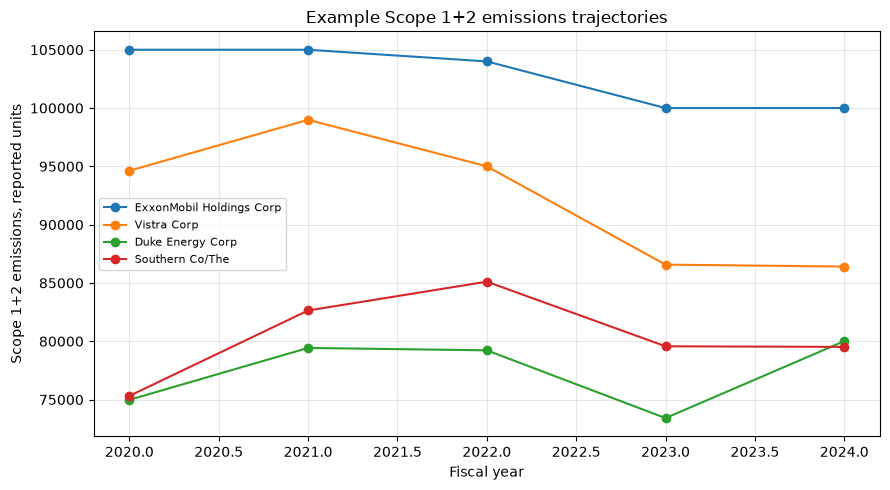

In [18]:
example_companies = (
    company_level.dropna(subset=["Scope12_2024", "Scope12_Absolute_Trend"])
    .sort_values("Scope12_2024", ascending=False)
    .head(4)["Company"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(9, 5))
for company in example_companies:
    row = company_level.loc[company_level["Company"] == company].iloc[0]
    values = [row[f"Scope12_{year}"] for year in YEARS]
    ax.plot(YEARS, values, marker="o", label=company)

ax.set_title("Example Scope 1+2 emissions trajectories")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Scope 1+2 emissions, reported units")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The slope uses both absolute emissions and intensity. Intensity answers whether the company is becoming more carbon-efficient economically. Absolute emissions answer whether physical emissions are actually falling.


## 7. Robustness of emissions trends

The core score uses the 2020-2024 OLS trend. This section adds simple diagnostics:

1. Theil-Sen robust slope.
2. A 2021-2024 sensitivity trend.
3. A flag when OLS and Theil-Sen have opposite signs.

These diagnostics are not separate score components.


In [19]:
# COVID-related disruptions can distort 2020. The 2021-2024 trend is a sensitivity
# check, not a separate score component.
SENSITIVITY_YEARS = list(range(2021, 2025))

for label in trend_specs:
    sensitivity_columns = [
        col for col in trend_specs[label]
        if int(col.split("_")[-1]) in SENSITIVITY_YEARS
    ]
    sensitivity_result = company_level.apply(
        lambda row: estimate_log_trend(row, sensitivity_columns, SENSITIVITY_YEARS),
        axis=1,
    )
    company_level[f"{label}_Trend_2021_2024"] = sensitivity_result["annual_change"]

    ols_trend = company_level[f"{label}_Trend"]
    theil_trend = company_level[f"{label}_TheilSen_Trend"]
    company_level[f"{label}_Opposite_Sign_Flag"] = (
        ols_trend.notna() &
        theil_trend.notna() &
        (np.sign(ols_trend) != np.sign(theil_trend)) &
        (ols_trend != 0) &
        (theil_trend != 0)
    )

confidence_flags = []
for _, row in company_level.iterrows():
    flags = []
    for label in trend_specs:
        if row.get(f"{label}_Opposite_Sign_Flag", False):
            flags.append(f"{label}: OLS/Theil-Sen sign mismatch")
        primary = row.get(f"{label}_Trend")
        sensitivity = row.get(f"{label}_Trend_2021_2024")
        if pd.notna(primary) and pd.notna(sensitivity) and np.sign(primary) != np.sign(sensitivity):
            flags.append(f"{label}: 2020-2024 vs 2021-2024 sign mismatch")
    confidence_flags.append("; ".join(flags) if flags else "No major trend sign conflict")

company_level["Trend_Confidence_Flag"] = confidence_flags

trend_diagnostic_summary = pd.DataFrame({
    "diagnostic": [
        "Scope12 absolute OLS/Theil-Sen sign conflicts",
        "Scope12 intensity OLS/Theil-Sen sign conflicts",
        "Scope3 absolute OLS/Theil-Sen sign conflicts",
        "Scope3 intensity OLS/Theil-Sen sign conflicts",
    ],
    "count": [
        int(company_level["Scope12_Absolute_Opposite_Sign_Flag"].sum()),
        int(company_level["Scope12_Intensity_Opposite_Sign_Flag"].sum()),
        int(company_level["Scope3_Absolute_Opposite_Sign_Flag"].sum()),
        int(company_level["Scope3_Intensity_Opposite_Sign_Flag"].sum()),
    ],
})

trend_diagnostic_summary


,diagnostic,count
0,Scope12 absolute OLS/Theil-Sen sign conflicts,23
1,Scope12 intensity OLS/Theil-Sen sign conflicts,21
2,Scope3 absolute OLS/Theil-Sen sign conflicts,28
3,Scope3 intensity OLS/Theil-Sen sign conflicts,34


## 8. Peer and global normalization

A purely global ranking is unfair to structurally high-emitting sectors. A purely peer-relative ranking can make the cleanest high-emitting company look as sustainable as a low-carbon company.

Each feature therefore receives both:

- a global percentile score
- a peer percentile score

The baseline feature score is:

\[
\text{Feature score} = 40\% \times \text{global percentile} + 60\% \times \text{peer percentile}
\]

GICS Industry Group is used when at least 10 usable observations exist. Otherwise the score falls back to GICS Sector.


In [20]:
def percentile_score(series, lower_is_better=True):
    '''Convert a raw metric to a 0-100 percentile score.'''
    values = safe_numeric(series)
    if values.notna().sum() == 0:
        return pd.Series(np.nan, index=series.index)

    ranks = values.rank(method="average", pct=True)
    if lower_is_better:
        scores = 100 * (1 - ranks)
    else:
        scores = 100 * ranks
    return scores


# Industry group is the preferred peer set, but small groups produce unstable
# percentiles. The fallback to sector keeps peer normalization usable.
def peer_percentile_score(df, value_column, lower_is_better=True, min_group_size=10):
    '''Calculate peer percentile scores using industry group, with sector fallback.'''
    result = pd.Series(np.nan, index=df.index, dtype=float)
    valid = df[value_column].notna()

    peer_group = df["GICS Industry Group"].copy()
    group_counts = df.loc[valid].groupby(peer_group[valid])[value_column].transform("count")
    use_industry = valid & (group_counts >= min_group_size)

    for group, idx in df.loc[use_industry].groupby("GICS Industry Group").groups.items():
        result.loc[idx] = percentile_score(df.loc[idx, value_column], lower_is_better=lower_is_better)

    remaining = valid & result.isna()
    for group, idx in df.loc[remaining].groupby("GICS Sector").groups.items():
        result.loc[idx] = percentile_score(df.loc[idx, value_column], lower_is_better=lower_is_better)

    return result


def blended_feature_score(df, value_column, lower_is_better=True):
    '''Blend global and peer percentile scores for one feature.'''
    global_col = f"{value_column}_Global_Score"
    peer_col = f"{value_column}_Peer_Score"
    final_col = f"{value_column}_Feature_Score"

    df[global_col] = percentile_score(df[value_column], lower_is_better=lower_is_better)
    df[peer_col] = peer_percentile_score(df, value_column, lower_is_better=lower_is_better)
    df[final_col] = 0.40 * df[global_col] + 0.60 * df[peer_col]
    return global_col, peer_col, final_col


feature_inputs = {
    "winsor_log_Scope12_Intensity_2024": True,
    "winsor_log_Scope3_Intensity_2024": True,
    "Scope12_Intensity_Trend": True,
    "Scope12_Absolute_Trend": True,
    "Scope3_Intensity_Trend": True,
    "Scope3_Absolute_Trend": True,
}

feature_score_columns = {}
for value_column, lower_is_better in feature_inputs.items():
    global_col, peer_col, final_col = blended_feature_score(
        company_level, value_column, lower_is_better=lower_is_better
    )
    feature_score_columns[value_column] = {
        "global": global_col,
        "peer": peer_col,
        "final": final_col,
    }

company_level[[meta["final"] for meta in feature_score_columns.values()]].describe().T


,count,mean,std,min,25%,50%,75%,max
winsor_log_Scope12_Intensity_2024_Feature_Score,453.0,48.498896,25.350940,0.176600,28.221055,47.953812,68.725166,97.970393
winsor_log_Scope3_Intensity_2024_Feature_Score,420.0,48.380952,26.020111,0.190476,27.738095,47.656503,69.718615,98.135338
Scope12_Intensity_Trend_Feature_Score,451.0,48.492239,28.009652,0.000000,24.734872,49.204237,72.827186,98.244642
Scope12_Absolute_Trend_Feature_Score,451.0,48.492239,28.409981,0.000000,24.087618,48.712263,73.276021,98.291379
Scope3_Intensity_Trend_Feature_Score,407.0,48.329238,28.363048,0.000000,23.514005,47.315458,72.458858,98.224492
Scope3_Absolute_Trend_Feature_Score,407.0,48.329238,28.235909,0.000000,24.076271,48.199979,73.141531,98.224492


## 9. Forward-looking SBTi component

The SBTi block is a forward-looking credibility and ambition signal. It is not realized performance.

The workbook is inspected before mapping categories. Missing or "Field Not Applicable" observations are left missing rather than treated as zero.


In [21]:
for col in sbt_columns:
    print(f"\n{col}")
    display(company_level[col].value_counts(dropna=False).rename_axis("category").reset_index(name="count"))



SBTI_NEAR_TERM_TARGET_STATUS


,category,count
0,#N/A Field Not Applicable,244
1,Targets Set,218
2,Removed,26
3,Committed,12



SBTI_NEAR_TERM_TARGET_CLASS


,category,count
0,#N/A Field Not Applicable,244
1,1.5,189
2,NaN,38
3,Well-below 2,24
4,2,3
5,1.5/Well-below 2,2


In [22]:
missing_like_categories = {"field not applicable", "not applicable", "n/a", "na", "none", ""}

def clean_category(value):
    '''Clean categorical fields and treat generic non-applicable labels as missing.'''
    if pd.isna(value):
        return np.nan
    cleaned = str(value).strip()
    if cleaned.lower() in missing_like_categories:
        return np.nan
    return cleaned


status_col = "SBTI_NEAR_TERM_TARGET_STATUS"
class_col = "SBTI_NEAR_TERM_TARGET_CLASS"

# Generic non-applicable labels are kept missing. Missing SBTi data is a lack of
# evidence, not proof that the company has no climate target.
company_level["SBTi_Status_Clean"] = company_level[status_col].map(clean_category) if status_col in company_level.columns else np.nan
company_level["SBTi_Class_Clean"] = company_level[class_col].map(clean_category) if class_col in company_level.columns else np.nan

status_mapping = {
    "Targets Set": 100,
    "Committed": 60,
    "Removed": 0,
}

class_mapping = {
    "1.5": 100,
    "1.5°C": 100,
    "1.5C": 100,
    "1.5°C / WB2°C": 90,
    "1.5 / WB2": 90,
    "Well-below 2°C": 75,
    "Well-below 2C": 75,
    "WB2": 75,
    "2°C": 50,
    "2C": 50,
    "2": 50,
}

present_statuses = sorted(company_level["SBTi_Status_Clean"].dropna().unique())
present_classes = sorted(company_level["SBTi_Class_Clean"].dropna().astype(str).unique())

used_status_mapping = {k: v for k, v in status_mapping.items() if k in present_statuses}
used_class_mapping = {k: v for k, v in class_mapping.items() if k in present_classes}

company_level["SBTi_Status_Score"] = company_level["SBTi_Status_Clean"].map(used_status_mapping)
company_level["SBTi_Target_Ambition_Score"] = company_level["SBTi_Class_Clean"].astype("string").map(used_class_mapping)

company_level["SBTi_Score"] = (
    0.60 * company_level["SBTi_Status_Score"] +
    0.40 * company_level["SBTi_Target_Ambition_Score"]
)

print("Used status mapping:", used_status_mapping)
print("Used target-class mapping:", used_class_mapping)

company_level[[
    "SBTi_Status_Clean", "SBTi_Class_Clean",
    "SBTi_Status_Score", "SBTi_Target_Ambition_Score", "SBTi_Score"
]].describe(include="all")


Used status mapping: {'Targets Set': 100, 'Committed': 60, 'Removed': 0}
Used target-class mapping: {'1.5': 100, '2': 50}


,SBTi_Status_Clean,SBTi_Class_Clean,SBTi_Status_Score,SBTi_Target_Ambition_Score,SBTi_Score
count,500,462,256.00000,192.000000,192.000000
unique,4,5,NaN,NaN,NaN
top,#N/A Field Not Applicable,#N/A Field Not Applicable,NaN,NaN,NaN
freq,244,244,NaN,NaN,NaN
mean,NaN,NaN,87.96875,99.218750,99.687500
std,NaN,NaN,30.81531,6.217191,2.486877
min,NaN,NaN,0.00000,50.000000,80.000000
25%,NaN,NaN,100.00000,100.000000,100.000000
50%,NaN,NaN,100.00000,100.000000,100.000000
75%,NaN,NaN,100.00000,100.000000,100.000000


The workbook contains target status and target class fields. It does not contain enough target-path information here to calculate a full target alignment path, such as baseline year, target year, target emissions and required annual reduction. That would be a useful extension if richer target data becomes available.


## 10. Climate Transition Score

The baseline architecture is implemented as explicit weights. Component scores remain separate so the final ranking can be explained.


In [23]:
# Keeping weights in a visible table makes the score architecture auditable and
# easier to adjust for robustness checks or judge feedback.
component_weights = pd.DataFrame([
    {"component": "Scope12_Current_Footprint_Score", "block": "Current Footprint", "weight": 0.21},
    {"component": "Scope3_Current_Footprint_Score", "block": "Current Footprint", "weight": 0.09},
    {"component": "Scope12_Intensity_Trend_Score", "block": "Realized Decarbonization", "weight": 0.21},
    {"component": "Scope12_Absolute_Trend_Score", "block": "Realized Decarbonization", "weight": 0.14},
    {"component": "Scope3_Intensity_Trend_Score", "block": "Realized Decarbonization", "weight": 0.09},
    {"component": "Scope3_Absolute_Trend_Score", "block": "Realized Decarbonization", "weight": 0.06},
    {"component": "SBTi_Status_Score", "block": "Forward Target", "weight": 0.12},
    {"component": "SBTi_Target_Ambition_Score", "block": "Forward Target", "weight": 0.08},
])

score_source_mapping = {
    "Scope12_Current_Footprint_Score": "winsor_log_Scope12_Intensity_2024_Feature_Score",
    "Scope3_Current_Footprint_Score": "winsor_log_Scope3_Intensity_2024_Feature_Score",
    "Scope12_Intensity_Trend_Score": "Scope12_Intensity_Trend_Feature_Score",
    "Scope12_Absolute_Trend_Score": "Scope12_Absolute_Trend_Feature_Score",
    "Scope3_Intensity_Trend_Score": "Scope3_Intensity_Trend_Feature_Score",
    "Scope3_Absolute_Trend_Score": "Scope3_Absolute_Trend_Feature_Score",
    "SBTi_Status_Score": "SBTi_Status_Score",
    "SBTi_Target_Ambition_Score": "SBTi_Target_Ambition_Score",
}

for component, source in score_source_mapping.items():
    if component != source:
        company_level[component] = company_level[source]

component_weights


,component,block,weight
0,Scope12_Current_Footprint_Score,Current Footprint,0.21
1,Scope3_Current_Footprint_Score,Current Footprint,0.09
2,Scope12_Intensity_Trend_Score,Realized Decarbonization,0.21
3,Scope12_Absolute_Trend_Score,Realized Decarbonization,0.14
4,Scope3_Intensity_Trend_Score,Realized Decarbonization,0.09
5,Scope3_Absolute_Trend_Score,Realized Decarbonization,0.06
6,SBTi_Status_Score,Forward Target,0.12
7,SBTi_Target_Ambition_Score,Forward Target,0.08


## 11. Missing-data and confidence adjustment

Missing values are not imputed. Instead, scores are averaged only over available components and then shrunk toward a neutral value of 50 when data coverage is incomplete:

\[
\text{coverage} = \frac{\text{observed weight}}{\text{total weight}}
\]

\[
\text{adjusted score} = 50 + \text{coverage} \times (\text{raw score} - 50)
\]


In [24]:
def weighted_score_with_coverage(df, weights_df, neutral_value=50):
    '''Calculate weighted raw score, data coverage and neutral-shrunk score.'''
    weighted_sum = pd.Series(0.0, index=df.index)
    observed_weight = pd.Series(0.0, index=df.index)

    # Scores are averaged over observed components first, then shrunk toward 50 by
# data coverage so sparse disclosure does not create false precision.
    for _, row in weights_df.iterrows():
        component = row["component"]
        weight = row["weight"]
        valid = df[component].notna()
        weighted_sum.loc[valid] += df.loc[valid, component] * weight
        observed_weight.loc[valid] += weight

    raw_score = weighted_sum / observed_weight.replace(0, np.nan)
    coverage = observed_weight / weights_df["weight"].sum()
    adjusted_score = neutral_value + coverage * (raw_score.fillna(neutral_value) - neutral_value)

    return raw_score, coverage, adjusted_score


raw_score, coverage, adjusted_score = weighted_score_with_coverage(company_level, component_weights)

company_level["Raw_Climate_Transition_Score"] = raw_score
company_level["Data_Coverage"] = coverage
company_level["Climate_Transition_Score"] = adjusted_score

company_level[["Raw_Climate_Transition_Score", "Data_Coverage", "Climate_Transition_Score"]].describe()


,Raw_Climate_Transition_Score,Data_Coverage,Climate_Transition_Score
count,474.000000,500.000000,500.000000
mean,52.927775,0.795820,52.756800
std,16.643440,0.259047,13.355149
min,8.667724,0.000000,16.934180
25%,41.910081,0.800000,43.938566
50%,52.613146,0.800000,51.029088
75%,65.321697,1.000000,62.405347
max,100.000000,1.000000,90.793160


## 12. Guardrail: targets cannot hide worsening emissions

The main guardrail is diagnostic and transparent. A company is flagged if its absolute Scope 1+2 trend is positive. A second flag identifies companies where high SBTi scores coexist with rising operational emissions and a high total score.


In [25]:
# The guardrail flags cases where commitments could look good even though physical
# operational emissions are still rising.
company_level["Rising_Emissions_Flag"] = company_level["Scope12_Absolute_Trend"] > 0
company_level["Targets_Hiding_Worsening_Flag"] = (
    (company_level["Scope12_Absolute_Trend"] > 0.05) &
    (company_level["SBTi_Score"] >= 70) &
    (company_level["Climate_Transition_Score"] >= 70)
)

guardrail_summary = pd.DataFrame({
    "diagnostic": [
        "Companies with rising Scope 1+2 absolute emissions trend",
        "High score + high SBTi + strongly rising Scope 1+2 emissions",
    ],
    "count": [
        int(company_level["Rising_Emissions_Flag"].sum()),
        int(company_level["Targets_Hiding_Worsening_Flag"].sum()),
    ],
})
guardrail_summary


,diagnostic,count
0,Companies with rising Scope 1+2 absolute emiss...,214
1,High score + high SBTi + strongly rising Scope...,2


In [26]:
company_level.loc[
    company_level["Targets_Hiding_Worsening_Flag"],
    ["Company", "GICS Sector", "Scope12_Absolute_Trend", "SBTi_Score", "Climate_Transition_Score"]
].sort_values("Climate_Transition_Score", ascending=False).head(10)


,Company,GICS Sector,Scope12_Absolute_Trend,SBTi_Score,Climate_Transition_Score
326,NVIDIA Corp,Information Technology,0.164271,100.0,76.977017
235,Host Hotels & Resorts Inc,Real Estate,0.058972,100.0,71.491734


## 13. Weight robustness

The baseline weights involve judgement. A Monte Carlo sensitivity test checks whether ranks depend too heavily on one exact set of assumptions.

The simulations keep realized decarbonization as the largest block, current footprint meaningful, and SBTi as the smallest block. The exercise does not optimize weights.


In [27]:
np.random.seed(42)
N_SIMULATIONS = 750

current_components = ["Scope12_Current_Footprint_Score", "Scope3_Current_Footprint_Score"]
realized_components = [
    "Scope12_Intensity_Trend_Score",
    "Scope12_Absolute_Trend_Score",
    "Scope3_Intensity_Trend_Score",
    "Scope3_Absolute_Trend_Score",
]
forward_components = ["SBTi_Status_Score", "SBTi_Target_Ambition_Score"]

simulation_scores = []

# The simulation changes reasonable weight choices without optimizing them. Stable
# ranks are more credible than rankings that depend on one exact judgement call.
for simulation in range(N_SIMULATIONS):
    while True:
        block_weights = np.random.dirichlet([6, 10, 3])
        current_weight, realized_weight, forward_weight = block_weights
        if realized_weight > current_weight and current_weight > forward_weight and current_weight >= 0.20 and forward_weight <= 0.25:
            break

    scope12_current_share = np.random.uniform(0.60, 0.80)
    scope12_realized_share = np.random.uniform(0.60, 0.80)
    intensity_share = np.random.uniform(0.50, 0.70)
    sbti_status_share = np.random.uniform(0.50, 0.70)

    weights = pd.DataFrame([
        {"component": "Scope12_Current_Footprint_Score", "weight": current_weight * scope12_current_share},
        {"component": "Scope3_Current_Footprint_Score", "weight": current_weight * (1 - scope12_current_share)},
        {"component": "Scope12_Intensity_Trend_Score", "weight": realized_weight * scope12_realized_share * intensity_share},
        {"component": "Scope12_Absolute_Trend_Score", "weight": realized_weight * scope12_realized_share * (1 - intensity_share)},
        {"component": "Scope3_Intensity_Trend_Score", "weight": realized_weight * (1 - scope12_realized_share) * intensity_share},
        {"component": "Scope3_Absolute_Trend_Score", "weight": realized_weight * (1 - scope12_realized_share) * (1 - intensity_share)},
        {"component": "SBTi_Status_Score", "weight": forward_weight * sbti_status_share},
        {"component": "SBTi_Target_Ambition_Score", "weight": forward_weight * (1 - sbti_status_share)},
    ])

    _, _, simulated_score = weighted_score_with_coverage(company_level, weights)
    simulation_scores.append(simulated_score)

simulation_score_df = pd.concat(simulation_scores, axis=1)
simulation_score_df.columns = [f"simulation_{i}" for i in range(N_SIMULATIONS)]

simulation_rank_df = simulation_score_df.rank(ascending=False, method="min")

company_level["Baseline_Rank"] = company_level["Climate_Transition_Score"].rank(ascending=False, method="min")
company_level["Median_Robustness_Rank"] = simulation_rank_df.median(axis=1)
company_level["P10_Robustness_Rank"] = simulation_rank_df.quantile(0.10, axis=1)
company_level["P90_Robustness_Rank"] = simulation_rank_df.quantile(0.90, axis=1)

top10_cutoff = int(np.ceil(0.10 * len(company_level)))
top20_cutoff = int(np.ceil(0.20 * len(company_level)))
company_level["Top10_Probability"] = (simulation_rank_df <= top10_cutoff).mean(axis=1)
company_level["Top20_Probability"] = (simulation_rank_df <= top20_cutoff).mean(axis=1)

company_level[[
    "Baseline_Rank", "Median_Robustness_Rank", "P10_Robustness_Rank",
    "P90_Robustness_Rank", "Top10_Probability", "Top20_Probability"
]].describe()


,Baseline_Rank,Median_Robustness_Rank,P10_Robustness_Rank,P90_Robustness_Rank,Top10_Probability,Top20_Probability
count,500.00000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,249.85000,250.111000,216.061600,283.330600,0.10000,0.200000
std,144.38116,143.496106,139.421547,142.969455,0.26872,0.368674
min,1.00000,1.000000,1.000000,2.000000,0.00000,0.000000
25%,125.75000,129.750000,100.750000,162.000000,0.00000,0.000000
50%,250.50000,246.000000,209.000000,296.000000,0.00000,0.000000
75%,375.25000,374.500000,327.225000,406.250000,0.00000,0.101000
max,500.00000,500.000000,500.000000,500.000000,1.00000,1.000000


## 14. Final ranking

The final table keeps raw variables, component scores, diagnostics and robustness fields. It is sorted from highest to lowest Climate Transition Score.


In [28]:
# These block scores are kept beside the final score so any company rank can be
# decomposed into footprint, realized progress and target credibility.
company_level["Current_Footprint_Score"] = (
    0.70 * company_level["Scope12_Current_Footprint_Score"] +
    0.30 * company_level["Scope3_Current_Footprint_Score"]
)

company_level["Realized_Decarbonization_Score"] = (
    0.70 * (
        0.60 * company_level["Scope12_Intensity_Trend_Score"] +
        0.40 * company_level["Scope12_Absolute_Trend_Score"]
    ) +
    0.30 * (
        0.60 * company_level["Scope3_Intensity_Trend_Score"] +
        0.40 * company_level["Scope3_Absolute_Trend_Score"]
    )
)

final_columns = [
    "Company", "ID", "Security_IDs", "Security_Count", "ISIN",
    "GICS Sector", "GICS Industry Group",
    "Scope12_Intensity_2024", "Scope3_Intensity_2024",
    "Scope12_Absolute_Trend", "Scope12_Intensity_Trend",
    "Scope3_Absolute_Trend", "Scope3_Intensity_Trend",
    "Current_Footprint_Score", "Realized_Decarbonization_Score", "SBTi_Score",
    "Raw_Climate_Transition_Score", "Data_Coverage", "Climate_Transition_Score",
    "Baseline_Rank", "Median_Robustness_Rank", "P10_Robustness_Rank",
    "P90_Robustness_Rank", "Top20_Probability",
    "Trend_Confidence_Flag", "Rising_Emissions_Flag", "Targets_Hiding_Worsening_Flag",
    "SBTi_Status_Clean", "SBTi_Class_Clean",
]

final_columns = [col for col in final_columns if col in company_level.columns]

final_ranking = (
    company_level[final_columns]
    .sort_values("Climate_Transition_Score", ascending=False)
    .reset_index(drop=True)
)

final_ranking["Baseline_Rank"] = np.arange(1, len(final_ranking) + 1)

print("Top 20 Climate Transition companies")
display(final_ranking.head(20))

print("Bottom 20 Climate Transition companies")
display(final_ranking.tail(20))


Top 20 Climate Transition companies


,Company,ID,Security_IDs,Security_Count,ISIN,GICS Sector,GICS Industry Group,Scope12_Intensity_2024,Scope3_Intensity_2024,Scope12_Absolute_Trend,Scope12_Intensity_Trend,Scope3_Absolute_Trend,Scope3_Intensity_Trend,Current_Footprint_Score,Realized_Decarbonization_Score,SBTi_Score,Raw_Climate_Transition_Score,Data_Coverage,Climate_Transition_Score,Baseline_Rank,Median_Robustness_Rank,P10_Robustness_Rank,P90_Robustness_Rank,Top20_Probability,Trend_Confidence_Flag,Rising_Emissions_Flag,Targets_Hiding_Worsening_Flag,SBTi_Status_Clean,SBTi_Class_Clean
0,Booking Holdings Inc,BKNG UW Equity,BKNG UW Equity,1,US09857L1089,Consumer Discretionary,Consumer Services,0.000115,0.022941,-0.348510,-0.525465,0.168935,-0.148565,93.864570,85.267577,100.0,90.793160,1.00,90.793160,1,1.0,1.0,2.0,1.0,No major trend sign conflict,False,False,Targets Set,1.5
1,Centene Corp,CNC UN Equity,CNC UN Equity,1,US15135B1017,Health Care,Health Care Equipment & Servic,0.000271,0.007263,-0.235713,-0.306231,-0.173641,-0.249887,94.490890,95.868552,NaN,95.351929,0.80,86.281543,2,2.0,1.0,4.0,1.0,No major trend sign conflict,False,False,#N/A Field Not Applicable,#N/A Field Not Applicable
2,Autodesk Inc,ADSK UW Equity,ADSK UW Equity,1,US0527691069,Information Technology,Software & Services,0.001585,0.028044,-0.075331,-0.189201,-0.083591,-0.196444,79.783778,84.224596,100.0,86.047431,1.00,86.047431,3,4.0,3.0,7.0,1.0,Scope3_Absolute: 2020-2024 vs 2021-2024 sign m...,False,False,Targets Set,1.5
3,PTC Inc,PTC UW Equity,PTC UW Equity,1,US69370C1009,Information Technology,Software & Services,0.002669,0.016350,-0.204580,-0.270489,-0.013390,-0.095141,77.358524,85.175363,100.0,85.795239,1.00,85.795239,4,5.0,3.0,8.0,1.0,No major trend sign conflict,False,False,Targets Set,1.5
4,Ciena Corp,CIEN UN Equity,CIEN UN Equity,1,US1717793095,Information Technology,Technology Hardware & Equipmen,0.000426,0.420294,-0.423177,-0.448454,-0.005864,-0.049429,76.922497,84.155858,100.0,85.154678,1.00,85.154678,5,6.0,3.0,9.0,1.0,No major trend sign conflict,False,False,Targets Set,1.5
5,Prologis Inc,PLD UN Equity,PLD UN Equity,1,US74340W1036,Real Estate,Equity Real Estate Investment,0.000854,0.392703,-0.112800,-0.255246,-0.089098,-0.235350,69.363104,88.204339,100.0,84.911101,1.00,84.911101,6,6.0,4.0,10.0,1.0,No major trend sign conflict,False,False,Targets Set,1.5
6,Coca-Cola Co/The,KO UN Equity,KO UN Equity,1,US1912161007,Consumer Staples,"Food, Beverage & Tobacco",0.028646,0.185755,-0.337638,-0.393291,-0.297003,-0.356070,61.645727,94.999541,80.0,81.993489,1.00,81.993489,7,8.0,5.0,13.0,1.0,No major trend sign conflict,False,False,Targets Set,2
7,Jacobs Solutions Inc,J UN Equity,J UN Equity,1,US46982L1089,Industrials,Commercial & Professional Serv,0.003050,0.011437,-0.180335,-0.130365,-0.105337,-0.050796,78.117809,76.787918,100.0,81.829302,1.00,81.829302,8,12.0,8.0,18.0,1.0,Scope3_Intensity: 2020-2024 vs 2021-2024 sign ...,False,False,Targets Set,1.5
8,Citigroup Inc,C UN Equity,C UN Equity,1,US1729674242,Financials,Banks,0.002252,0.000407,-0.073038,-0.239670,-0.894354,-0.913345,90.994428,88.659583,NaN,89.535150,0.80,81.628120,9,5.0,3.0,10.0,1.0,No major trend sign conflict,False,False,#N/A Field Not Applicable,#N/A Field Not Applicable
9,Philip Morris International In,PM UN Equity,PM UN Equity,1,US7181721090,Consumer Staples,"Food, Beverage & Tobacco",0.009354,0.123159,-0.192319,-0.244563,0.039578,-0.027665,78.296184,76.185599,100.0,81.581655,1.00,81.581655,10,12.0,8.0,20.0,1.0,No major trend sign conflict,False,False,Targets Set,1.5


Bottom 20 Climate Transition companies


,Company,ID,Security_IDs,Security_Count,ISIN,GICS Sector,GICS Industry Group,Scope12_Intensity_2024,Scope3_Intensity_2024,Scope12_Absolute_Trend,Scope12_Intensity_Trend,Scope3_Absolute_Trend,Scope3_Intensity_Trend,Current_Footprint_Score,Realized_Decarbonization_Score,SBTi_Score,Raw_Climate_Transition_Score,Data_Coverage,Climate_Transition_Score,Baseline_Rank,Median_Robustness_Rank,P10_Robustness_Rank,P90_Robustness_Rank,Top20_Probability,Trend_Confidence_Flag,Rising_Emissions_Flag,Targets_Hiding_Worsening_Flag,SBTi_Status_Clean,SBTi_Class_Clean
480,Archer-Daniels-Midland Co,ADM UN Equity,ADM UN Equity,1,US0394831020,Consumer Staples,"Food, Beverage & Tobacco",0.168011,1.338688,-0.032654,-0.094974,0.222042,0.143312,7.730810,48.152657,NaN,28.690839,0.92,30.395572,481,465.0,413.0,485.0,0.0,Scope3_Absolute: 2020-2024 vs 2021-2024 sign m...,False,False,Removed,NaN
481,Veralto Corp,VLTO UN Equity,VLTO UN Equity,1,US92338C1036,Industrials,Commercial & Professional Serv,0.011092,0.387841,0.169152,0.120923,NaN,NaN,34.836266,NaN,NaN,23.939145,0.77,29.933141,482,482.0,474.0,486.0,0.0,No major trend sign conflict,True,False,Committed,NaN
482,Jack Henry & Associates Inc,JKHY UW Equity,JKHY UW Equity,1,US4262811015,Financials,Financial Services,0.015728,0.046369,0.034294,-0.035645,NaN,NaN,26.063009,NaN,NaN,23.003307,0.77,29.212546,483,471.0,449.0,484.0,0.0,No major trend sign conflict,True,False,Removed,NaN
483,Williams Cos Inc/The,WMB UN Equity,WMB UN Equity,1,US9694571004,Energy,Energy,1.527183,2.387127,0.035997,-0.028420,0.074762,0.007934,15.047037,29.257405,NaN,23.928517,0.80,29.142814,484,482.0,470.0,486.0,0.0,Scope12_Intensity: OLS/Theil-Sen sign mismatch...,True,False,#N/A Field Not Applicable,#N/A Field Not Applicable
484,Ares Management Corp,ARES UN Equity,ARES UN Equity,1,US03990B1017,Financials,Financial Services,0.001294,8.273869,0.392650,0.192617,19.135494,16.243334,57.995377,0.998136,NaN,22.372101,0.80,27.897681,485,487.0,472.9,495.0,0.0,No major trend sign conflict,True,False,#N/A Field Not Applicable,#N/A Field Not Applicable
485,Oracle Corp,ORCL UN Equity,ORCL UN Equity,1,US68389X1054,Information Technology,Software & Services,0.023882,0.050743,0.200815,0.106407,0.049320,-0.033177,27.222882,18.600120,NaN,21.833656,0.80,27.466925,486,487.0,483.9,489.0,0.0,Scope3_Intensity: OLS/Theil-Sen sign mismatch;...,True,False,#N/A Field Not Applicable,#N/A Field Not Applicable
486,LyondellBasell Industries NV,LYB UN Equity,LYB UN Equity,1,NL0009434992,Materials,Materials,0.664790,3.554531,-0.008342,-0.033198,0.055984,0.029516,12.400915,38.653511,NaN,25.051119,0.92,27.047030,487,481.0,457.0,489.0,0.0,Scope12_Intensity: 2020-2024 vs 2021-2024 sign...,False,False,Removed,NaN
487,Freeport-McMoRan Inc,FCX UN Equity,FCX UN Equity,1,US35671D8570,Materials,Materials,0.320566,0.257906,0.029882,-0.003332,0.334938,0.187771,46.916018,17.812884,NaN,24.979617,0.92,26.981248,488,482.0,466.9,490.0,0.0,Scope12_Intensity: OLS/Theil-Sen sign mismatch,True,False,Removed,NaN
488,CF Industries Holdings Inc,CF UN Equity,CF UN Equity,1,US1252691001,Materials,Materials,4.623652,7.462938,0.081832,0.004411,-0.063944,-0.130932,0.523620,33.617231,NaN,21.207127,0.80,26.965701,489,487.0,472.0,495.0,0.0,Scope3_Intensity: 2020-2024 vs 2021-2024 sign ...,True,False,#N/A Field Not Applicable,#N/A Field Not Applicable
489,CMS Energy Corp,CMS UN Equity,CMS UN Equity,1,US1258961002,Utilities,Utilities,2.462579,2.778643,0.013310,-0.019934,0.057205,0.022521,14.793003,22.013840,NaN,19.306026,0.80,25.444821,490,491.0,489.0,494.0,0.0,Scope12_Absolute: 2020-2024 vs 2021-2024 sign ...,True,False,#N/A Field Not Applicable,#N/A Field Not Applicable


## 15. Visualisations

The charts are intentionally simple. They are meant to make the score interpretable rather than decorative.


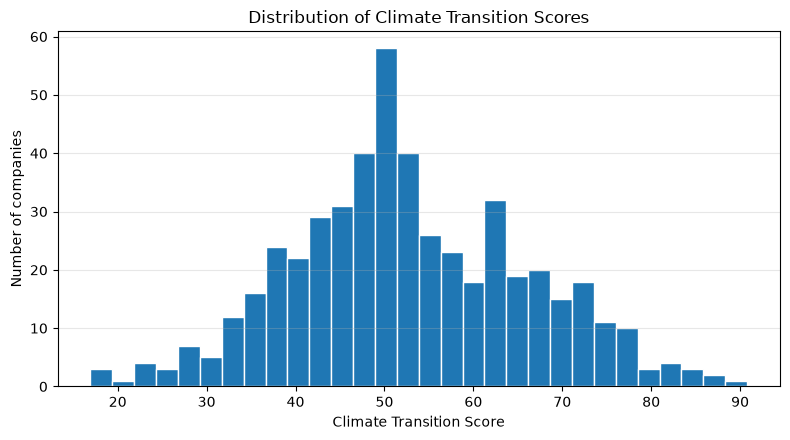

In [29]:
plt.figure(figsize=(8, 4.5))
plt.hist(final_ranking["Climate_Transition_Score"].dropna(), bins=30, edgecolor="white")
plt.title("Distribution of Climate Transition Scores")
plt.xlabel("Climate Transition Score")
plt.ylabel("Number of companies")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Most scores should sit near the middle because incomplete data is shrunk toward 50. The tails identify companies with strong evidence of either transition readiness or transition risk.


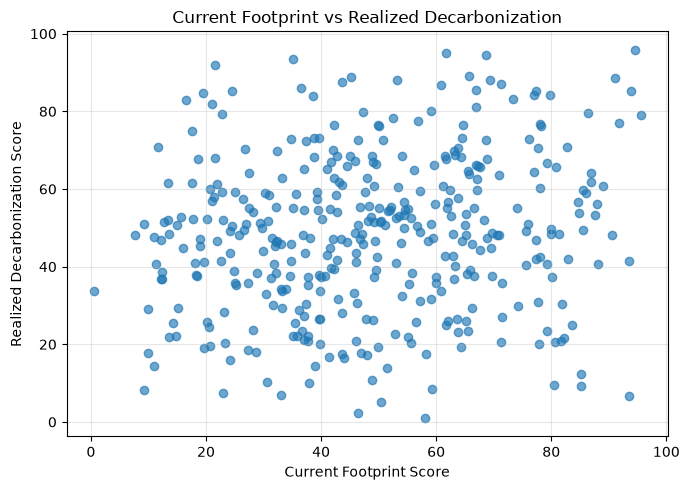

In [30]:
plt.figure(figsize=(7, 5))
plt.scatter(
    company_level["Current_Footprint_Score"],
    company_level["Realized_Decarbonization_Score"],
    alpha=0.65,
)
plt.title("Current Footprint vs Realized Decarbonization")
plt.xlabel("Current Footprint Score")
plt.ylabel("Realized Decarbonization Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The best companies combine low current emissions intensity with evidence that emissions are already falling.


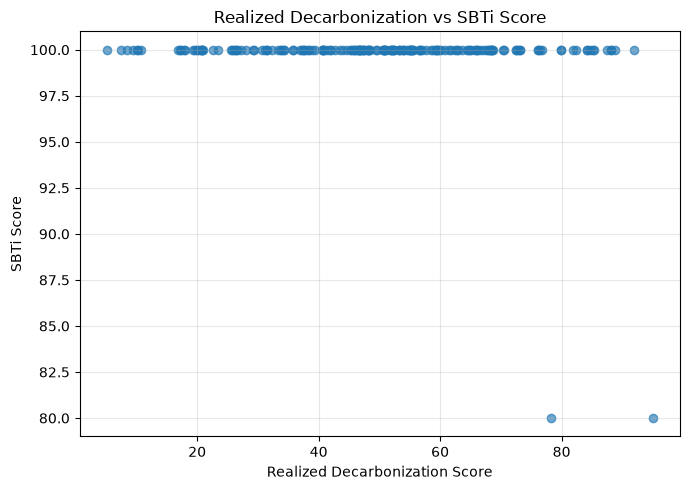

In [31]:
plt.figure(figsize=(7, 5))
plt.scatter(
    company_level["Realized_Decarbonization_Score"],
    company_level["SBTi_Score"],
    alpha=0.65,
)
plt.title("Realized Decarbonization vs SBTi Score")
plt.xlabel("Realized Decarbonization Score")
plt.ylabel("SBTi Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


This comparison separates companies that have already reduced emissions from companies whose main evidence is a forward-looking target.


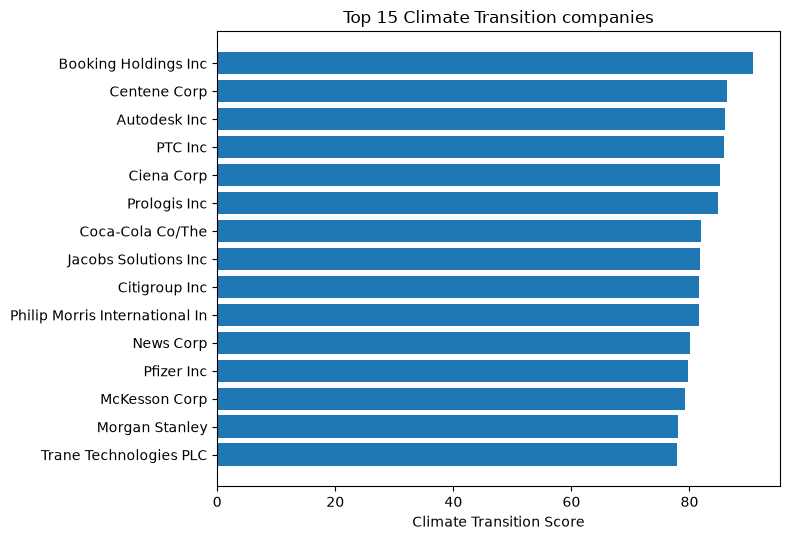

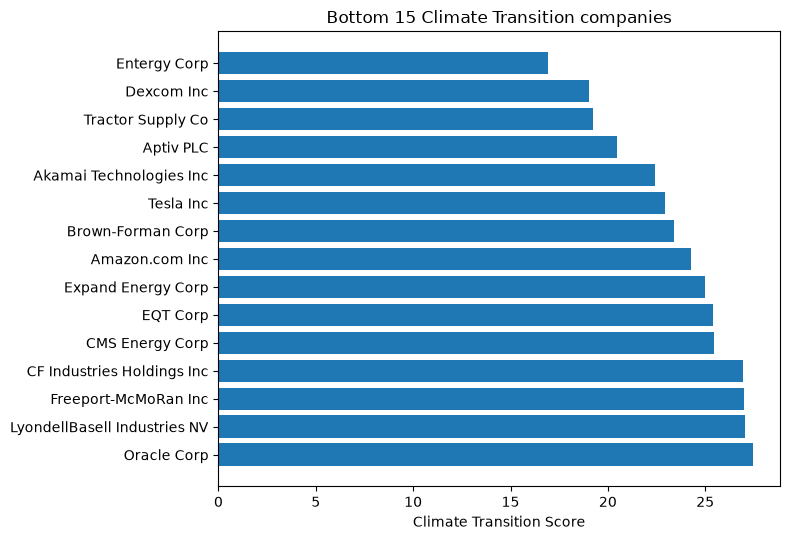

In [32]:
top15 = final_ranking.head(15).sort_values("Climate_Transition_Score")
plt.figure(figsize=(8, 5.5))
plt.barh(top15["Company"], top15["Climate_Transition_Score"])
plt.title("Top 15 Climate Transition companies")
plt.xlabel("Climate Transition Score")
plt.tight_layout()
plt.show()

bottom15 = final_ranking.tail(15).sort_values("Climate_Transition_Score", ascending=False)
plt.figure(figsize=(8, 5.5))
plt.barh(bottom15["Company"], bottom15["Climate_Transition_Score"])
plt.title("Bottom 15 Climate Transition companies")
plt.xlabel("Climate Transition Score")
plt.tight_layout()
plt.show()


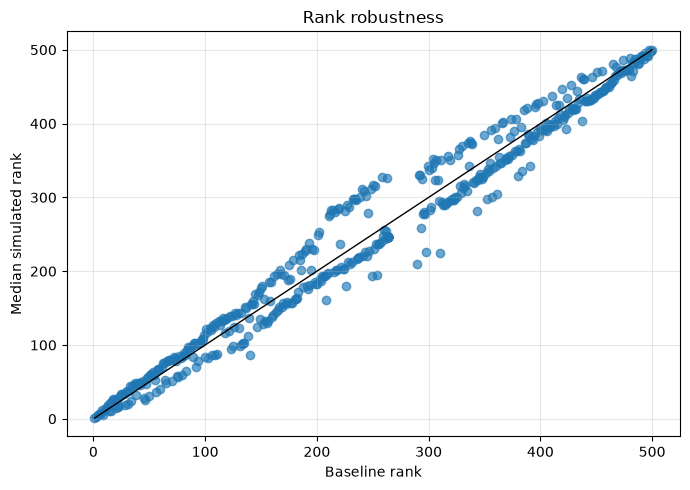

In [33]:
plt.figure(figsize=(7, 5))
plt.scatter(
    company_level["Baseline_Rank"],
    company_level["Median_Robustness_Rank"],
    alpha=0.65,
)
max_rank = len(company_level)
plt.plot([1, max_rank], [1, max_rank], color="black", linewidth=1)
plt.title("Rank robustness")
plt.xlabel("Baseline rank")
plt.ylabel("Median simulated rank")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Companies close to the diagonal have rankings that are stable under reasonable alternative weights. Large deviations deserve closer review before using the score in a portfolio setting.


In [34]:
footprint_median = company_level["Current_Footprint_Score"].median()
transition_median = company_level["Realized_Decarbonization_Score"].median()

def transition_quadrant(row):
    '''Label companies using current footprint and realized decarbonization medians.'''
    high_footprint = row["Current_Footprint_Score"] < footprint_median
    strong_transition = row["Realized_Decarbonization_Score"] >= transition_median
    if high_footprint and strong_transition:
        return "Transition Catalyst"
    if high_footprint and not strong_transition:
        return "At Risk"
    if not high_footprint and strong_transition:
        return "Climate Leader"
    return "Stable"


company_level["Transition_Quadrant"] = company_level.apply(transition_quadrant, axis=1)

quadrant_counts = (
    company_level["Transition_Quadrant"]
    .value_counts()
    .reindex(["At Risk", "Transition Catalyst", "Stable", "Climate Leader"])
    .rename_axis("quadrant")
    .reset_index(name="company_count")
)
quadrant_counts


,quadrant,company_count
0,At Risk,125
1,Transition Catalyst,79
2,Stable,177
3,Climate Leader,119


## 16. Sanity checks

Before using a score, it should be possible to explain why representative companies rank where they do.


In [35]:
sanity_examples = pd.concat([
    final_ranking.head(3),
    final_ranking.tail(3),
    final_ranking.sort_values("Data_Coverage").head(3),
    final_ranking.query("SBTi_Score >= 80 and Realized_Decarbonization_Score < 40").head(3),
    final_ranking.query("Realized_Decarbonization_Score >= 75 and SBTi_Score.isna()").head(3),
]).drop_duplicates(subset=["Company"])

decomposition_columns = [
    "Company", "GICS Sector", "Climate_Transition_Score", "Raw_Climate_Transition_Score",
    "Data_Coverage", "Current_Footprint_Score", "Realized_Decarbonization_Score",
    "SBTi_Score", "Scope12_Absolute_Trend", "Scope12_Intensity_Trend",
    "Scope3_Absolute_Trend", "Scope3_Intensity_Trend",
    "Trend_Confidence_Flag", "Rising_Emissions_Flag",
]
decomposition_columns = [col for col in decomposition_columns if col in sanity_examples.columns]
sanity_examples[decomposition_columns].sort_values("Climate_Transition_Score", ascending=False)


,Company,GICS Sector,Climate_Transition_Score,Raw_Climate_Transition_Score,Data_Coverage,Current_Footprint_Score,Realized_Decarbonization_Score,SBTi_Score,Scope12_Absolute_Trend,Scope12_Intensity_Trend,Scope3_Absolute_Trend,Scope3_Intensity_Trend,Trend_Confidence_Flag,Rising_Emissions_Flag
0,Booking Holdings Inc,Consumer Discretionary,90.793160,90.793160,1.00,93.864570,85.267577,100.0,-0.348510,-0.525465,0.168935,-0.148565,No major trend sign conflict,False
1,Centene Corp,Health Care,86.281543,95.351929,0.80,94.490890,95.868552,NaN,-0.235713,-0.306231,-0.173641,-0.249887,No major trend sign conflict,False
2,Autodesk Inc,Information Technology,86.047431,86.047431,1.00,79.783778,84.224596,100.0,-0.075331,-0.189201,-0.083591,-0.196444,Scope3_Absolute: 2020-2024 vs 2021-2024 sign m...,False
8,Citigroup Inc,Financials,81.628120,89.535150,0.80,90.994428,88.659583,NaN,-0.073038,-0.239670,-0.894354,-0.913345,No major trend sign conflict,False
13,Morgan Stanley,Financials,78.136742,85.170927,0.80,95.522133,78.960203,NaN,-0.438180,-0.534413,0.376986,0.141124,Scope12_Absolute: OLS/Theil-Sen sign mismatch;...,False
149,Cencora Inc,Health Care,59.365706,59.365706,1.00,71.516095,35.821755,100.0,0.023314,-0.081173,3.422222,2.970688,No major trend sign conflict,True
156,Lululemon Athletica Inc,Consumer Discretionary,58.748452,58.748452,1.00,66.509082,37.591454,100.0,0.165149,-0.081301,0.186100,-0.064782,No major trend sign conflict,True
183,McCormick & Co Inc/MD,Consumer Staples,55.886637,55.886637,1.00,55.813560,38.285137,100.0,-0.005014,-0.045779,-0.005828,-0.046560,Scope12_Absolute: 2020-2024 vs 2021-2024 sign ...,False
277,Corpay Inc,Financials,50.000000,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No major trend sign conflict,False
283,VeriSign Inc,Information Technology,50.000000,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No major trend sign conflict,False


These checks show whether the score behaves sensibly for high-scoring, low-scoring, low-coverage and mixed-signal companies. The decomposition is also the main way to answer: "Why did Company X receive this score?"


In [36]:
# Summarize the classification in a few compact tables so the final narrative
# is tied to actual notebook results rather than generic claims.
top_sector_summary = (
    final_ranking.head(100)
    .groupby("GICS Sector", dropna=False)
    .size()
    .sort_values(ascending=False)
    .rename("Top 20% company count")
    .reset_index()
)

bottom_sector_summary = (
    final_ranking.tail(100)
    .groupby("GICS Sector", dropna=False)
    .size()
    .sort_values(ascending=False)
    .rename("Bottom 20% company count")
    .reset_index()
)

interesting_cases = pd.concat([
    final_ranking.head(5).assign(Example_Group="Highest overall scores"),
    final_ranking.query("SBTi_Score >= 80 and Realized_Decarbonization_Score < 40").head(5).assign(
        Example_Group="Strong SBTi score, weak realized decarbonization"
    ),
    final_ranking.query("Realized_Decarbonization_Score >= 75 and SBTi_Score.isna()").head(5).assign(
        Example_Group="Strong realized decarbonization, no SBTi information"
    ),
    final_ranking.query("Rising_Emissions_Flag == True").head(5).assign(
        Example_Group="High-ranked but rising Scope 1+2 emissions"
    ),
])

summary_metrics = pd.DataFrame({
    "metric": [
        "Companies in final dataset",
        "Median Climate Transition Score",
        "Companies with full data coverage",
        "Companies flagged for rising Scope 1+2 emissions",
        "Companies with SBTi score available",
    ],
    "value": [
        len(final_ranking),
        round(final_ranking["Climate_Transition_Score"].median(), 2),
        int((final_ranking["Data_Coverage"] >= 0.999).sum()),
        int(final_ranking["Rising_Emissions_Flag"].sum()),
        int(final_ranking["SBTi_Score"].notna().sum()),
    ],
})

print("Key score diagnostics")
display(summary_metrics)

print("Most common sectors in the top 20%")
display(top_sector_summary.head(8))

print("Most common sectors in the bottom 20%")
display(bottom_sector_summary.head(8))

print("Examples worth discussing")
display(interesting_cases[[
    "Example_Group", "Company", "GICS Sector", "Climate_Transition_Score",
    "Current_Footprint_Score", "Realized_Decarbonization_Score",
    "SBTi_Score", "Data_Coverage", "Rising_Emissions_Flag"
]].head(20))

Key score diagnostics


,metric,value
0,Companies in final dataset,500.00
1,Median Climate Transition Score,51.03
2,Companies with full data coverage,181.00
3,Companies flagged for rising Scope 1+2 emissions,214.00
4,Companies with SBTi score available,192.00


Most common sectors in the top 20%


,GICS Sector,Top 20% company count
0,Financials,19
1,Health Care,18
2,Information Technology,18
3,Consumer Discretionary,13
4,Industrials,11
5,Real Estate,6
6,Consumer Staples,6
7,Communication Services,3


Most common sectors in the bottom 20%


,GICS Sector,Bottom 20% company count
0,Industrials,17
1,Financials,14
2,Information Technology,13
3,Consumer Discretionary,10
4,Utilities,10
5,Energy,9
6,Materials,8
7,Real Estate,8


Examples worth discussing


,Example_Group,Company,GICS Sector,Climate_Transition_Score,Current_Footprint_Score,Realized_Decarbonization_Score,SBTi_Score,Data_Coverage,Rising_Emissions_Flag
0,Highest overall scores,Booking Holdings Inc,Consumer Discretionary,90.793160,93.864570,85.267577,100.0,1.00,False
1,Highest overall scores,Centene Corp,Health Care,86.281543,94.490890,95.868552,NaN,0.80,False
2,Highest overall scores,Autodesk Inc,Information Technology,86.047431,79.783778,84.224596,100.0,1.00,False
3,Highest overall scores,PTC Inc,Information Technology,85.795239,77.358524,85.175363,100.0,1.00,False
4,Highest overall scores,Ciena Corp,Information Technology,85.154678,76.922497,84.155858,100.0,1.00,False
149,"Strong SBTi score, weak realized decarbonization",Cencora Inc,Health Care,59.365706,71.516095,35.821755,100.0,1.00,True
156,"Strong SBTi score, weak realized decarbonization",Lululemon Athletica Inc,Consumer Discretionary,58.748452,66.509082,37.591454,100.0,1.00,True
183,"Strong SBTi score, weak realized decarbonization",McCormick & Co Inc/MD,Consumer Staples,55.886637,55.813560,38.285137,100.0,1.00,False
189,"Strong SBTi score, weak realized decarbonization",Fortinet Inc,Information Technology,55.118167,60.835295,33.735157,100.0,1.00,True
192,"Strong SBTi score, weak realized decarbonization",Omnicom Group Inc,Communication Services,54.947453,81.727540,20.858382,100.0,1.00,True


## 17. Final considerations and link to the bonus question

The classification highlights a useful distinction between **being low-carbon today** and **actively transitioning**. Some companies rank well because they combine low current emissions intensity with improving emissions trends. Others look strong mainly because of SBTi commitments, which is why the notebook keeps realized decarbonization as the largest block and adds a rising-emissions flag.

The sector summaries should also be read carefully. Low-emissions sectors can appear frequently near the top, while energy, utilities, materials or industrial firms may face a harder starting point. This is exactly why the score blends global and peer percentiles: peer scoring recognizes sector constraints, while global scoring prevents high-emitting sectors from being completely protected by within-sector comparisons.

The most interesting firms for a portfolio discussion are not necessarily only the top-ranked firms. A net-zero shock could make three groups especially relevant:

- **Climate leaders**: low footprint and strong realized decarbonization.
- **Transition candidates**: high footprint but improving emissions quickly.
- **At-risk firms**: high footprint, weak realized decarbonization, or rising operational emissions.

The next step is to answer the bonus question: how should a hypothetical $1 billion fund allocate capital if the world commits to net zero as fast as possible? The Climate Transition Score built here should be one input into that answer, combined with financial transition exposure, valuation, liquidity and portfolio risk constraints.

## 18. Portfolio-ready output

This notebook does not build a $1bn portfolio directly from the Climate Transition Score. The score measures corporate transition readiness, not expected return.

A later portfolio framework could use:

\[
\text{Net-Zero Investment Signal}
= \text{Climate Transition Readiness}
+ \text{Financial Transition Exposure}
+ \text{Portfolio Risk Constraints}
\]

The dataset exported here corresponds only to Climate Transition Readiness.


## 19. Export

The final company-level dataset is saved as CSV and Excel so it can later be joined with a financial signal.


In [37]:
csv_output_path = OUTPUT_DIR / "climate_transition_scores.csv"
xlsx_output_path = OUTPUT_DIR / "climate_transition_scores.xlsx"

final_ranking.to_csv(csv_output_path, index=False)
final_ranking.to_excel(xlsx_output_path, index=False)

print(f"Saved CSV: {csv_output_path}")
print(f"Saved Excel: {xlsx_output_path}")
print(f"Rows exported: {len(final_ranking)}")


Saved CSV: c:\Users\axeli\Desktop\Coding\GitHub\Competitions\ETHack2026\outputs\climate_transition_scores.csv
Saved Excel: c:\Users\axeli\Desktop\Coding\GitHub\Competitions\ETHack2026\outputs\climate_transition_scores.xlsx
Rows exported: 500


## Summary, strengths, limitations and extensions

This notebook builds a transparent Climate Transition Score from Bloomberg-derived company data using three blocks: current footprint, realized decarbonization and SBTi target information. Peer comparisons recognize that sectors face different technological constraints, while the global component prevents sector neutrality from hiding intrinsically high carbon exposure. The confidence adjustment prevents missing disclosure from being mistaken for strong sustainability performance.

Main strengths:

- Uses actual emissions trends rather than relying only on commitments.
- Keeps Scope 1+2 separate from Scope 3.
- Combines peer-relative and global normalization.
- Makes missing data treatment explicit.
- Keeps component scores and diagnostics visible.

Main limitations:

- Scope 3 data are less comparable across firms and reporting boundaries.
- Revenue-based intensity can be sensitive to prices and business cycles.
- Five years is a short window for estimating emissions trends.
- Reporting-boundary changes may look like emissions changes.
- SBTi commitments are not guarantees of execution.
- Score weights involve judgement.
- Corporate emissions are not equivalent to financed emissions for financial institutions.

Possible extensions include adding richer SBTi target-path alignment, financed-emissions treatment for financial institutions, transition beta or risk exposure, and portfolio constraints.
